# FTIML Assignment 2: Fairness (10 points)

## Dataset: 2021 British Columnbia (Canada) Census data

The dataset represents the 2021 British Columbia (Canada) Census data. Each row describes the demographic and socioeconomic characteristics of an individual. The objective is to predict whether an individual's income exceeds 75K. These predictions will be used by a company that determines loan approvals based on your model's output. An individual's income may be influenced by their demographic and socioeconomic attributes. However, the company is legally prohibited from engaging in unfair treatment on the basis of "race, national or ethnic origin, colour, religion, age, sex, sexual orientation, gender identity or expression, marital status, family status, genetic characteristics, disability, or conviction for an offence for which a pardon has been granted or in respect of which a record suspension has been ordered", as outlined in the Canadian Human Rights Act. Your task is to analyze the fairness of your model's predictions and to apply techniques to improve the fairness of your models.

See for more information on the dataset "2021 Census Individuals PUMF User Guide.pdf". You are not required to read the entire document. 

Hint: Unavailable data is often encoded by 88888888 or 99999999.

## Deliverable:

A **.zip file** containing two elements: 
1. The **Jupyter notebook** you used for your analysis of Tasks a - d below (in ipynb).  
2. A **report of max. 4 pages** with the complete answers to the questions below (in pdf). 

**DEADLINE: Monday May 11, 2026 at 23:59.**

Note: All information in 2. needs to be contained in 1. (not necessarily vice versa).

Note: The grade for the assignment is primarily based on your presentation on May 12 and your report. The notebook serves as an add-on.


## Task a: Data Exploration
Before entering the analysis, spend some time to understand the data. 

* Which features do you expect to influence fairness?
* Define groups based on the sensitive feature(s) and visualize the data.
* Are there any inbalances? How might these affect your fairness analysis? 

Use graphs and/or tables, and write down your observations. 


## Task b: Explore Fairness
Take the outcomes of a black-box model (you may use the random forest model fitted below or for example a XGBoost model, neural network, ...) and an interpretable model of your choice and analyze their fairness across different protected groups.

*   Choose and report three group fairness metrics that are useful for the given context and report them.
*   Do you find evidence for biases in the models? Which group(s) appear to be at a disadvantage?
*   Are there any differences in fairness metrics between the black-box and interpretable models?

Use visualizations to support your analysis. Summarize the results in text. 


## Task c: Individual Fairness
Try to improve the fairness of your models using two individual fairness techniques.

Refer to the lecture slides and the notebook from the fairness tutorial for guidance on what is expected here.

Clearly state the techniques you are using and elaborate on their effects on the fairness of the models.


## Task d: Group Fairness
Try to improve the fairness metrics of your models using two group fairness techniques.

Explain why you choose the techniques you are using and elaborate on their effects on the fairness of the models.


# Preparations

## Install and load libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_curve, roc_auc_score, classification_report
from sklearn.model_selection import train_test_split

## Load and preprocess data
**Do not change this part**

In [2]:

data = pd.read_csv('data_donnees_2021_ind_BC.csv')
#print columns all column s
print(list(data.columns))

['PPSORT', 'ABOID', 'AGEGRP', 'AGEIMM', 'ATTSCH', 'BFNMEMB', 'BEDRM', 'CFSTAT', 'CHDBN', 'CIP2021', 'CIP2021_STEM_SUM', 'CMA', 'CONDO', 'COVID_ERB', 'COW', 'CQPPB', 'CfSize', 'ChldC', 'CitOth', 'Citizen', 'DIST', 'DPGRSUM', 'DTYPE', 'EFDecile', 'EFInc', 'EFInc_AT', 'EICBN', 'ETHDER', 'EfDIMBM_2018', 'EfSize', 'FOL', 'FPTWK', 'Gender', 'GENSTAT', 'GTRfs', 'HCORENEED_IND', 'HDGREE', 'HHSIZE', 'HHTYPE', 'HLMOSTEN', 'HLMOSTFR', 'HLMOSTNO', 'HLREGEN', 'HLREGFR', 'HLREGNO', 'IMMCAT5', 'IMMSTAT', 'JOBPERM', 'KOL', 'LFACT', 'LICO_BT', 'LICO_AT', 'LIPROGTYPE', 'LI_ELIG_OML_U18', 'LOCSTUD', 'LOC_ST_RES', 'LSTWRK', 'LWMOSTEN', 'LWMOSTFR', 'LWMOSTNO', 'LWREGEN', 'LWREGFR', 'LWREGNO', 'LoLIMA', 'LoLIMB', 'LOMBM_2018', 'MODE', 'MTNEn', 'MTNFr', 'MTNNO', 'MARSTH', 'Mob1', 'Mob5', 'NAICS', 'NOC21', 'NOS', 'OASGI', 'PKID25', 'PKID0_1', 'PKID15_24', 'PKID2_5', 'PKID6_14', 'PKIDS', 'POB', 'POBPAR1', 'POBPAR2', 'POWST', 'PR1', 'PR5', 'PRESMORTG', 'PRIHM', 'PWDUR', 'PWLEAVE', 'PWOCC', 'PWPR', 'REGIND', 'RE

In [3]:
# get features and target
AGEGRP = data['AGEGRP'] # this serves as an example, you can choose other sensitive attributes
X = pd.get_dummies(data.drop(columns=["75k"]))
y = data["75k"]

## Exploratory data analysis and feature engineering
Inspect the data and do some plots that help you understand the dataset here.

**Optional**: The dataset is already preprocessed. However, it might still pay off to invest some time in additional preprocessing here here (scaling, feature engineering, ...). This might improve model quality and help to rectify modeling errors.

**Note**: The data is imbalanced.

In [4]:
print(y.value_counts())

75k
0    44476
1    12014
Name: count, dtype: int64


                                             |          | [  0%]   00:00 -> (? left)


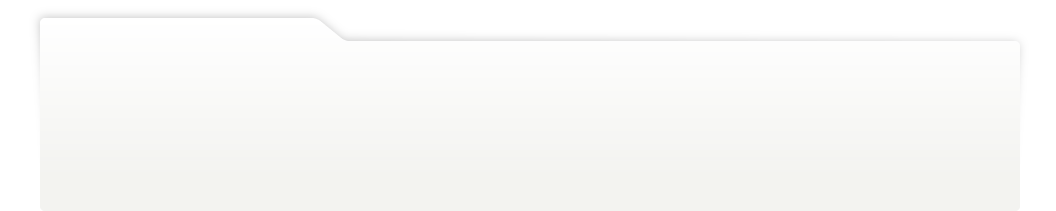
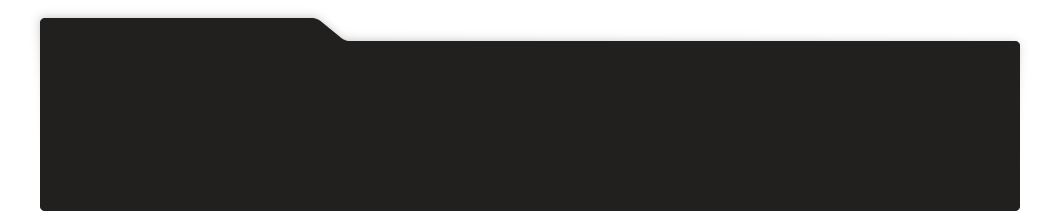
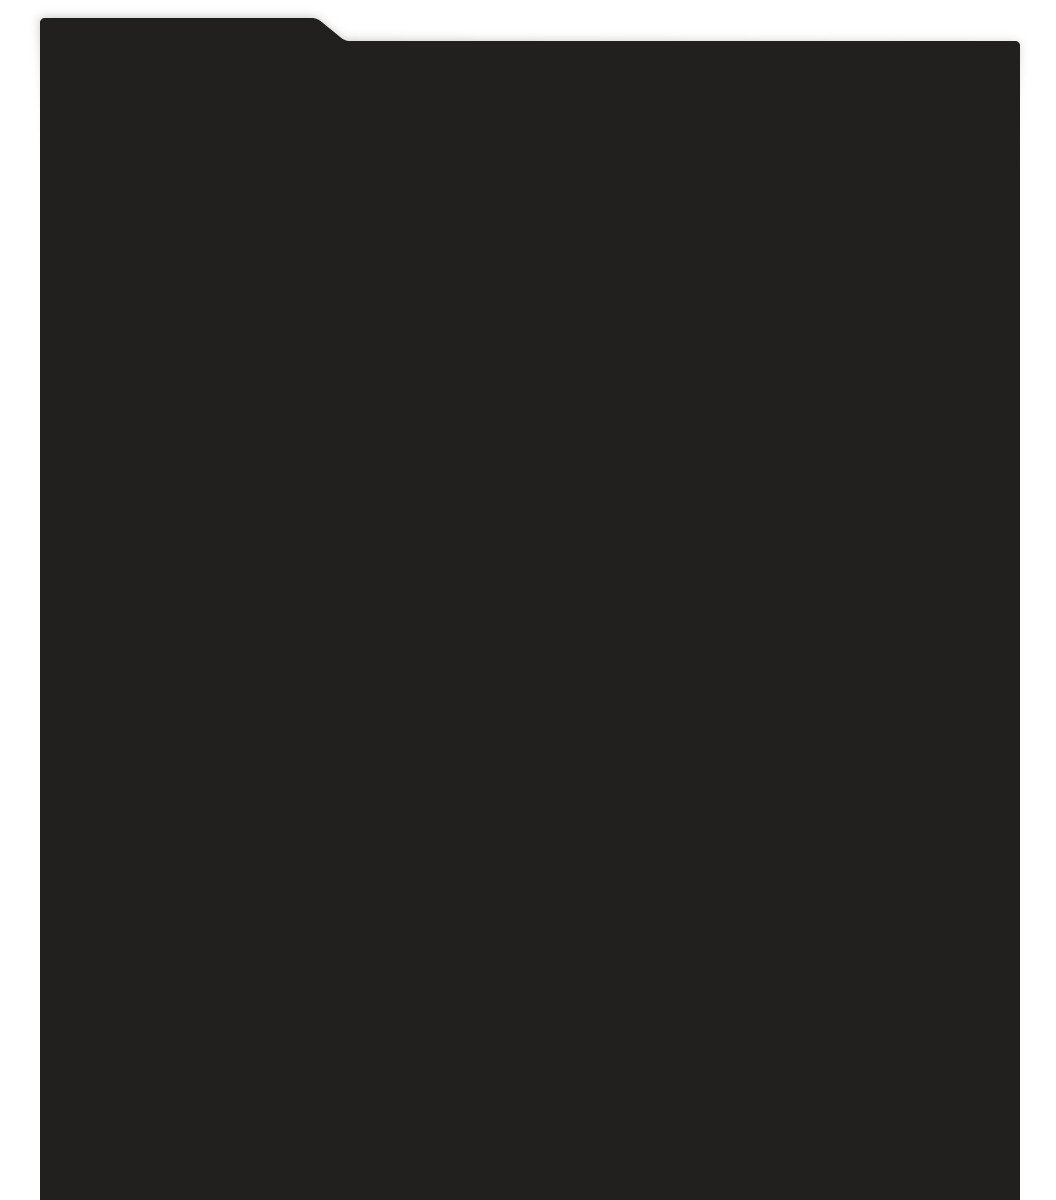
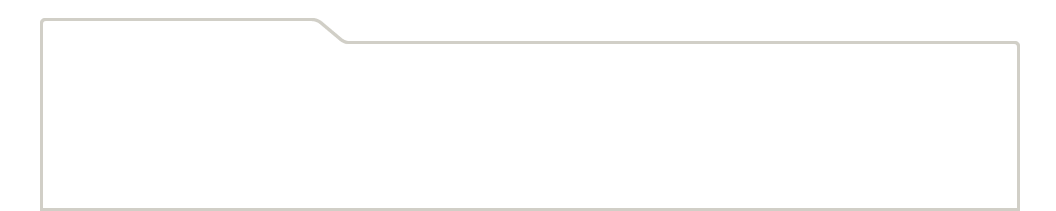
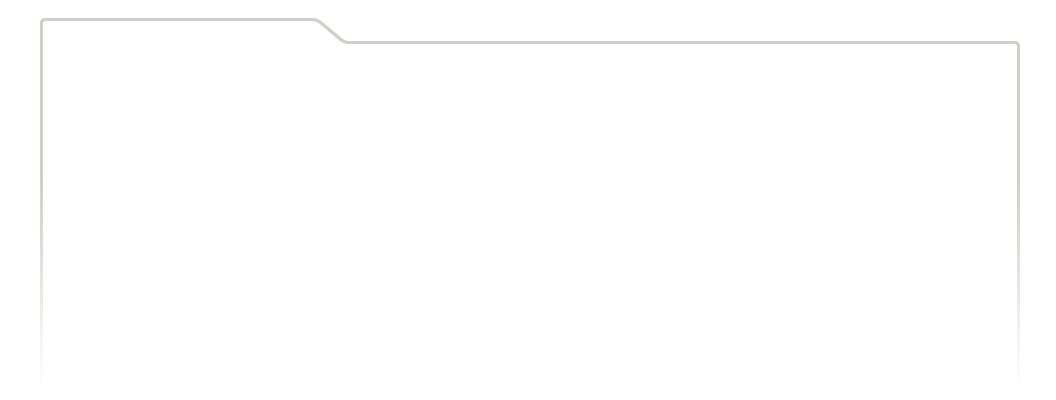
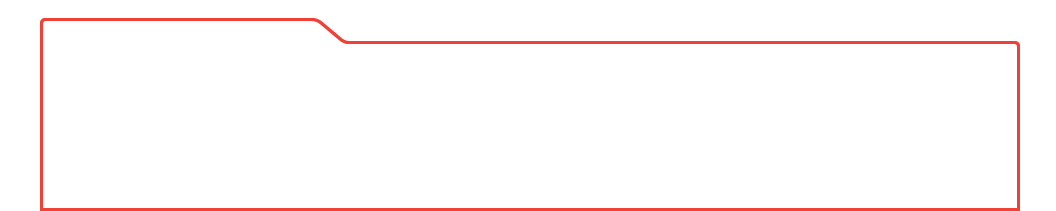
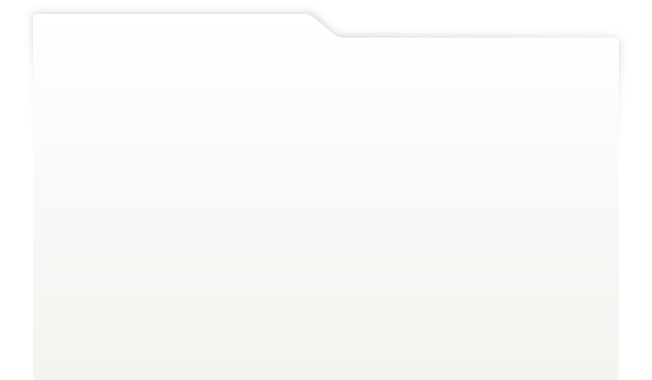
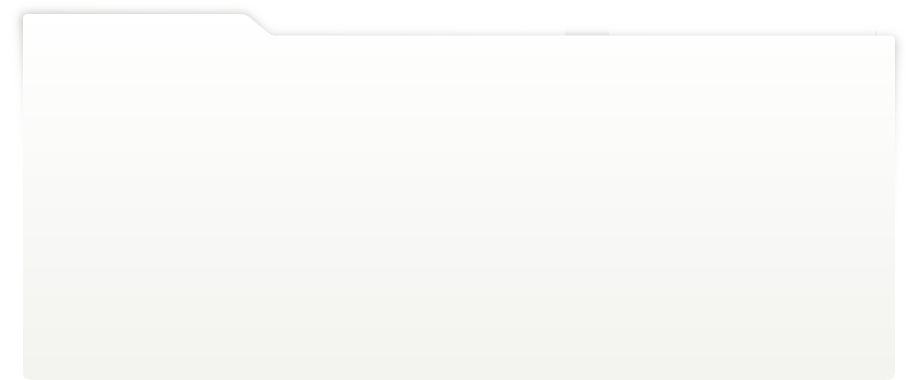
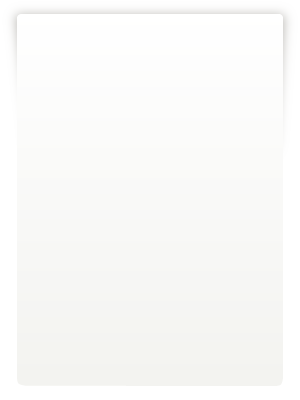
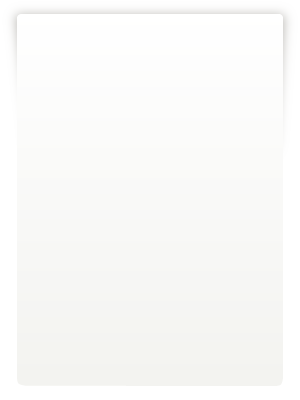
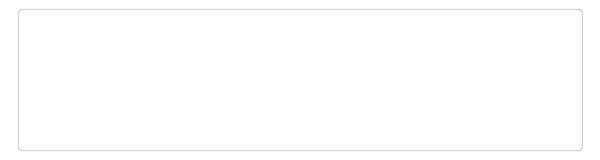
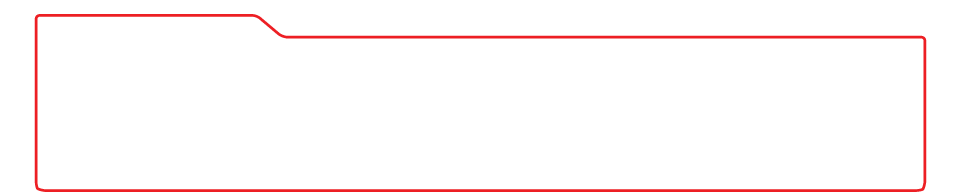
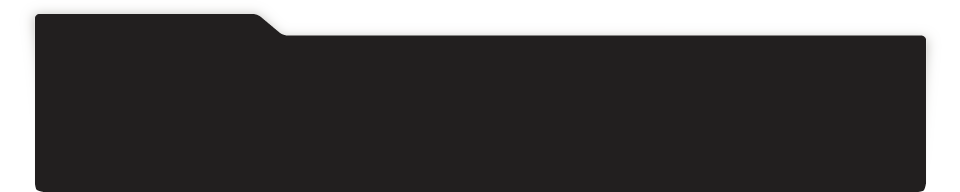
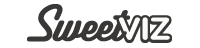
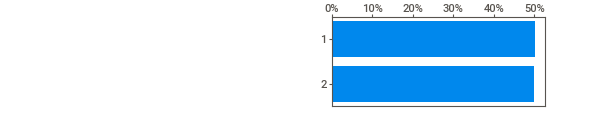
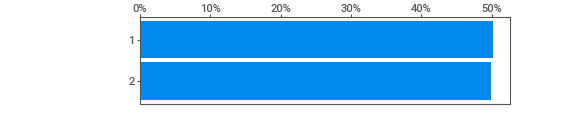
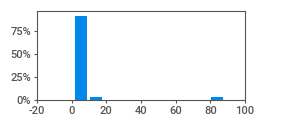
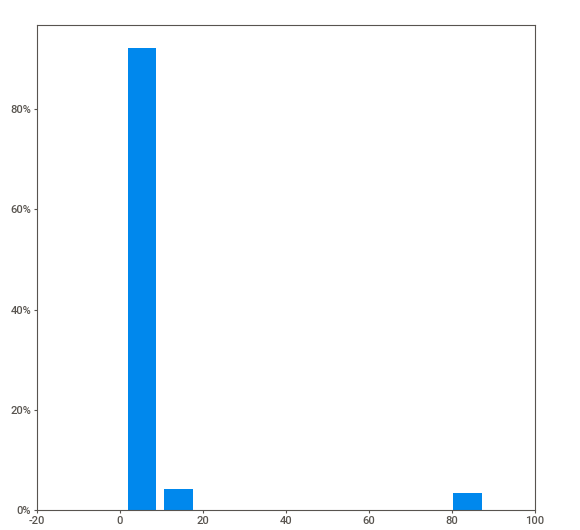
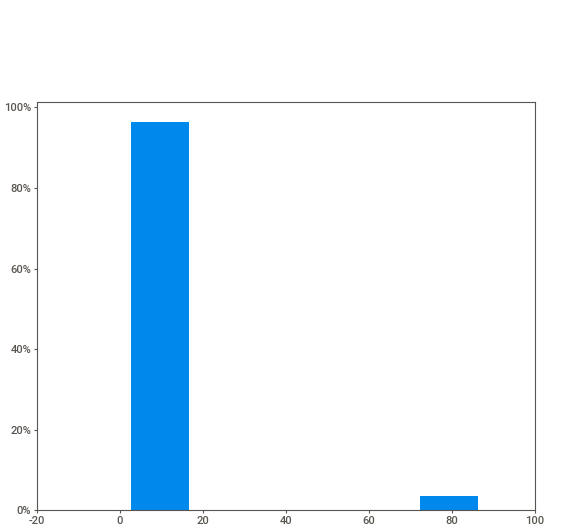
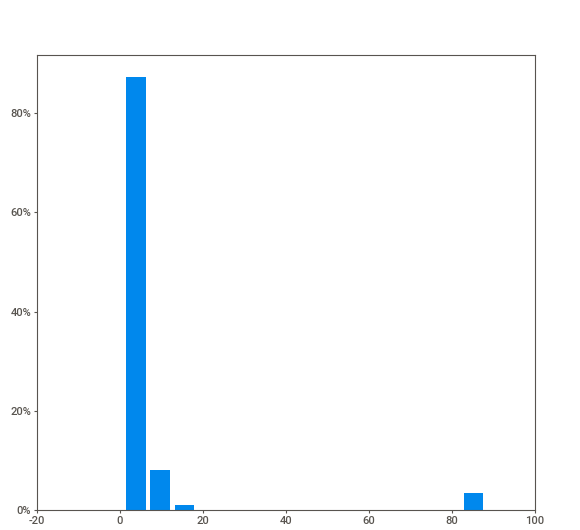
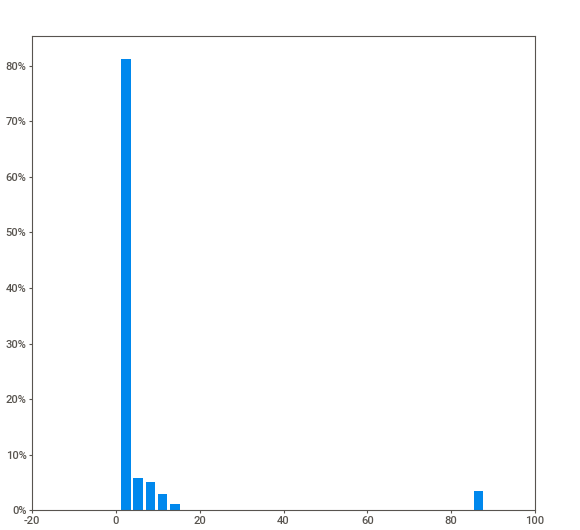
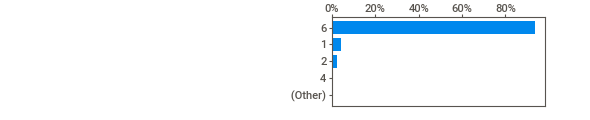
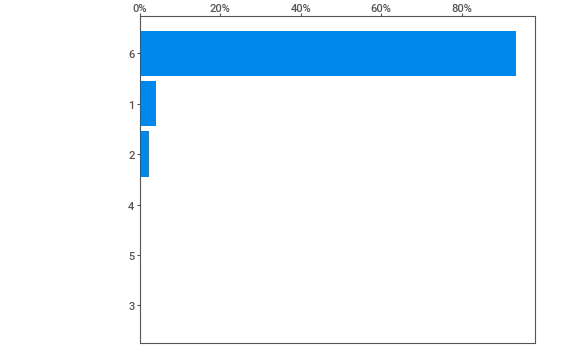
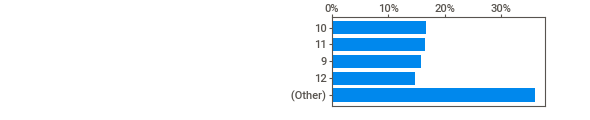
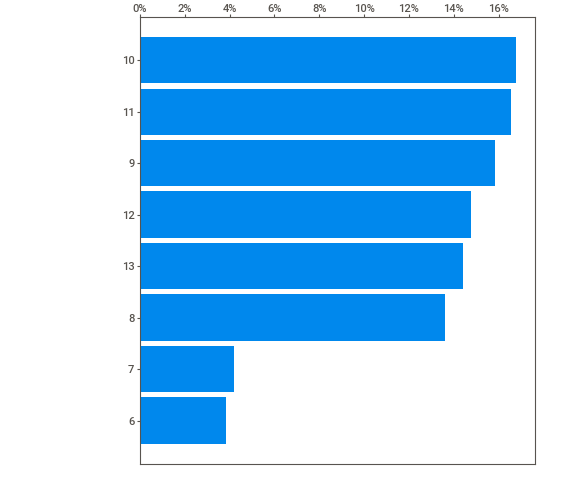
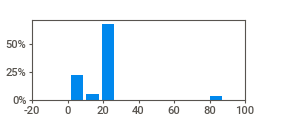
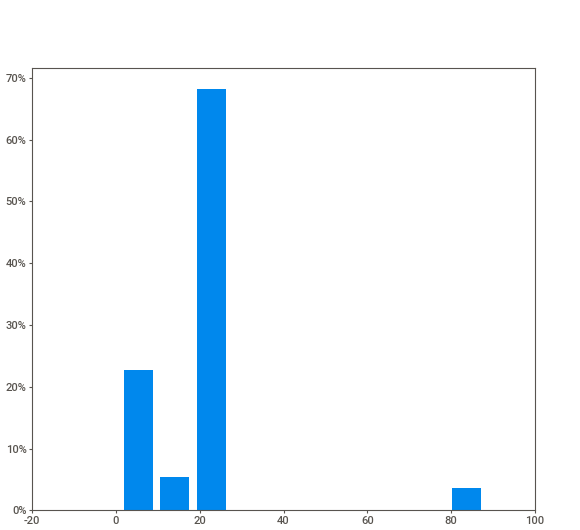
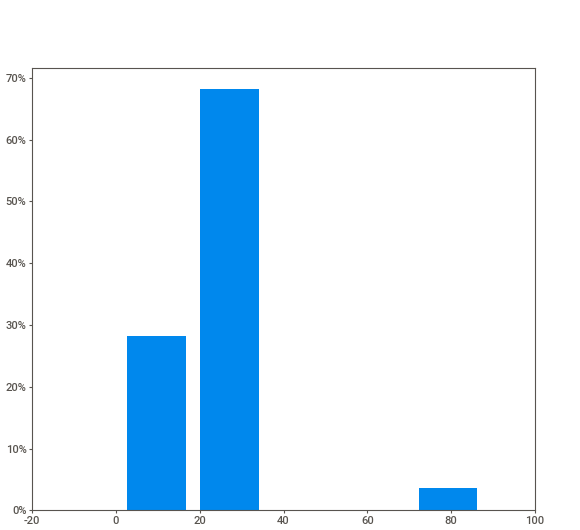
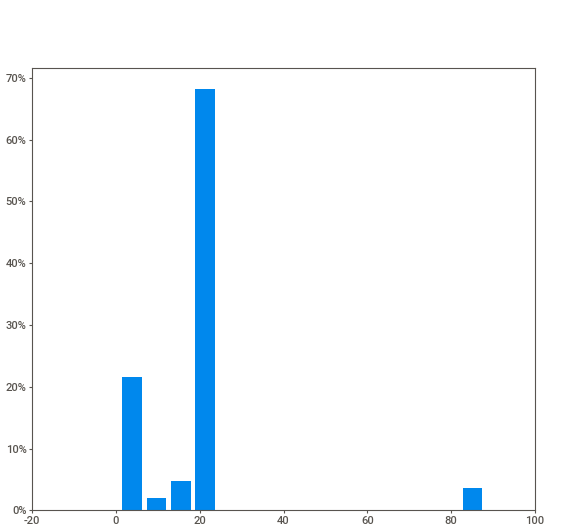
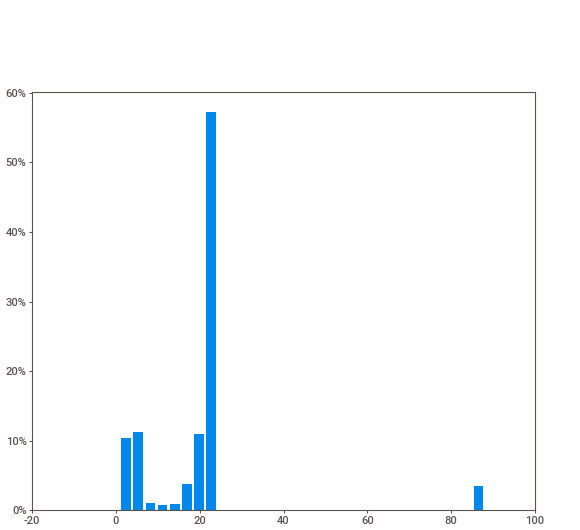
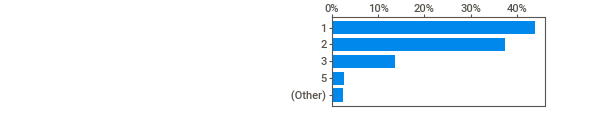
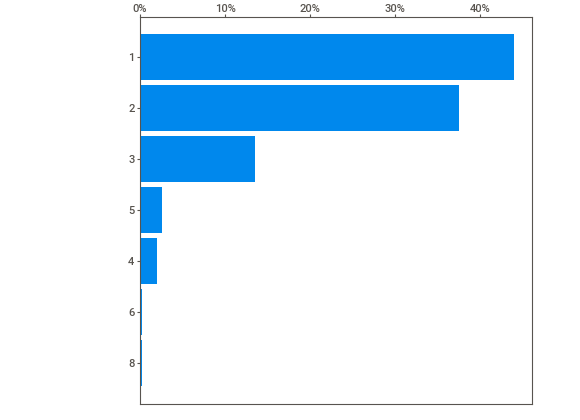
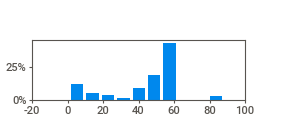
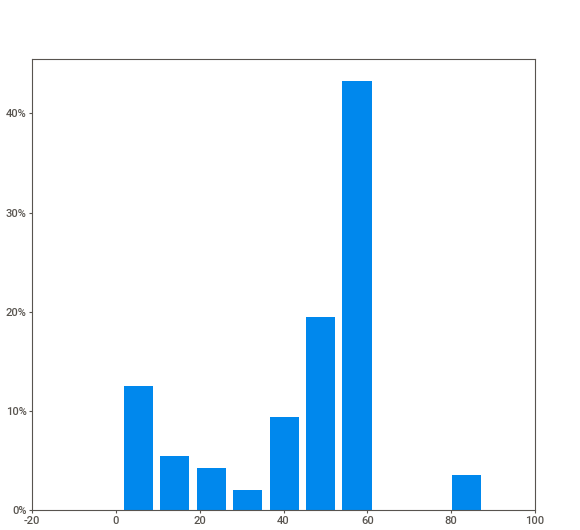
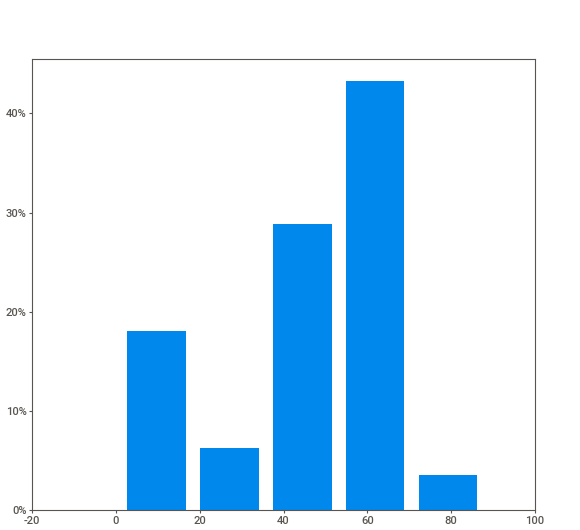
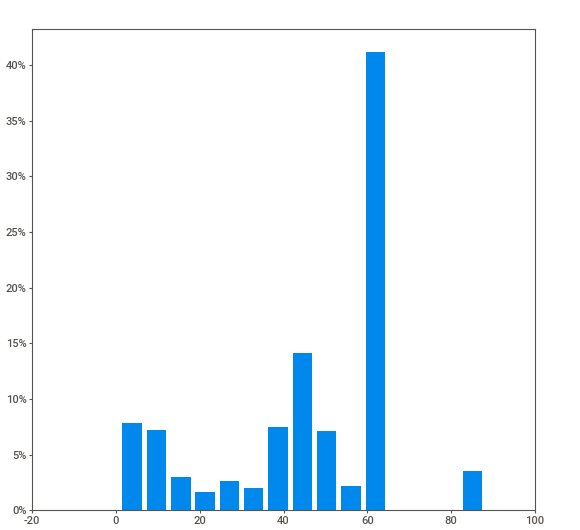
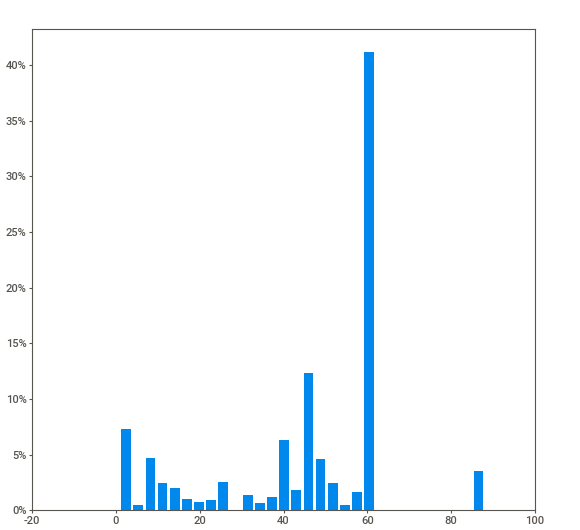
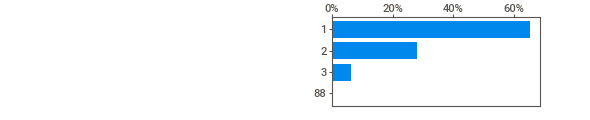
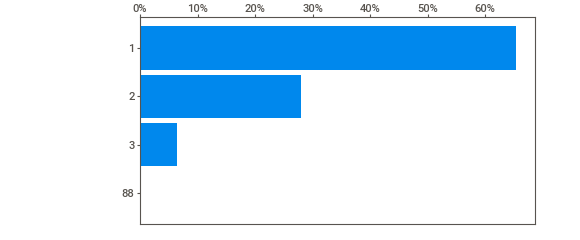
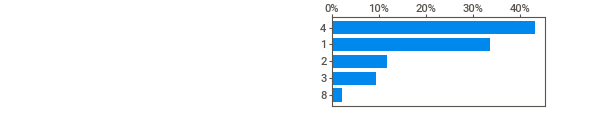
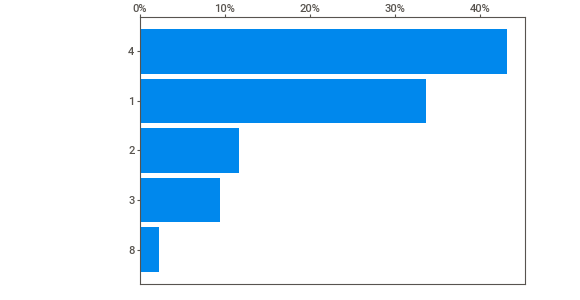
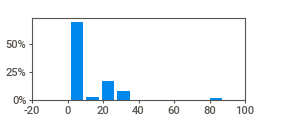
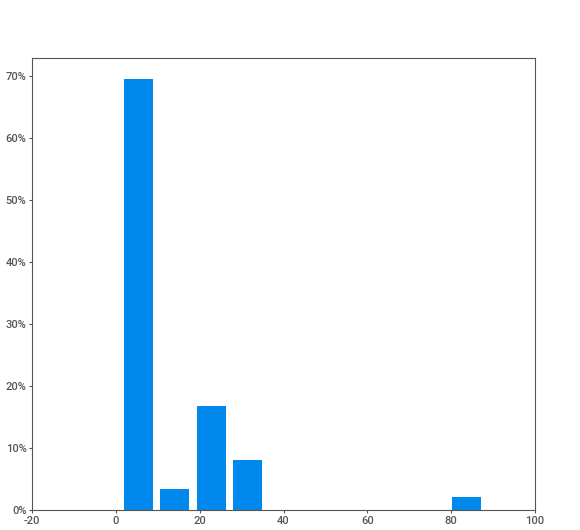
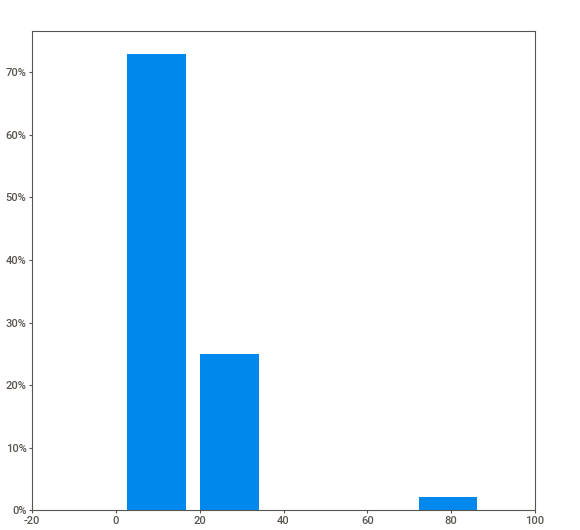
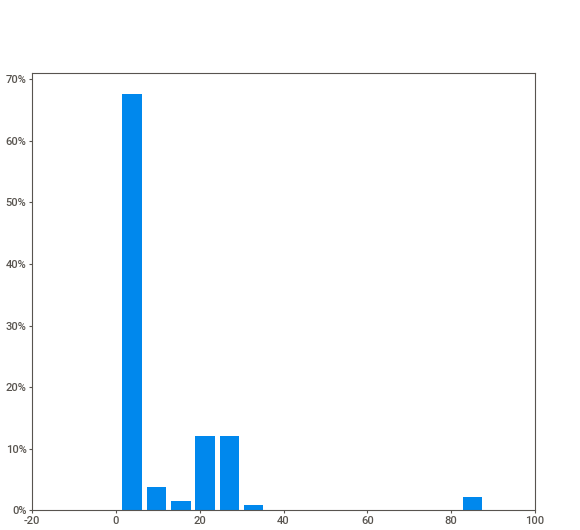
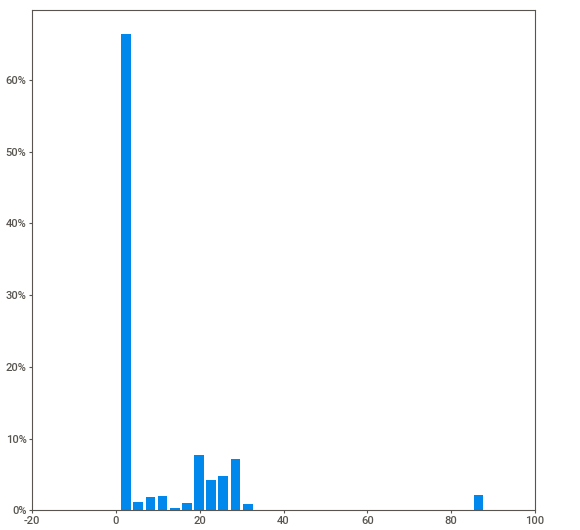
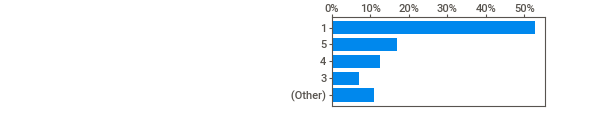
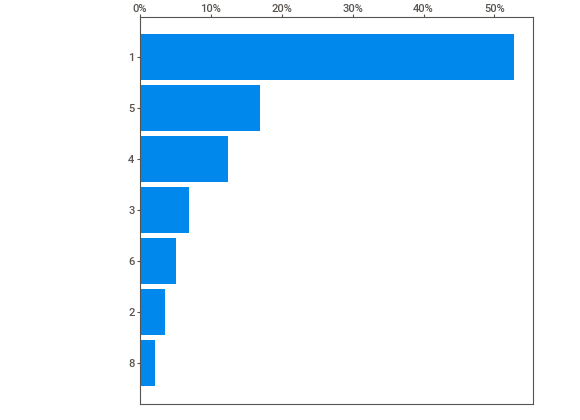
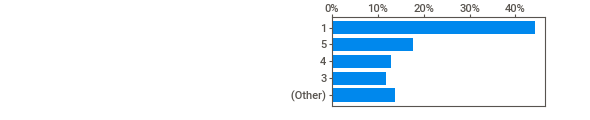
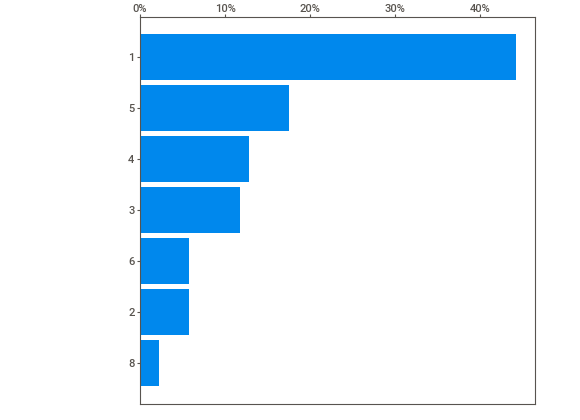
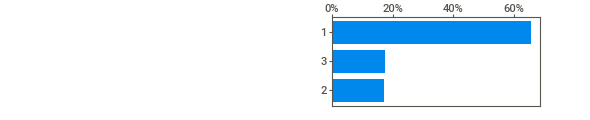
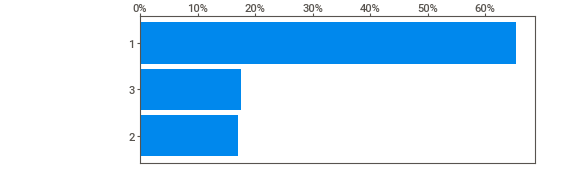
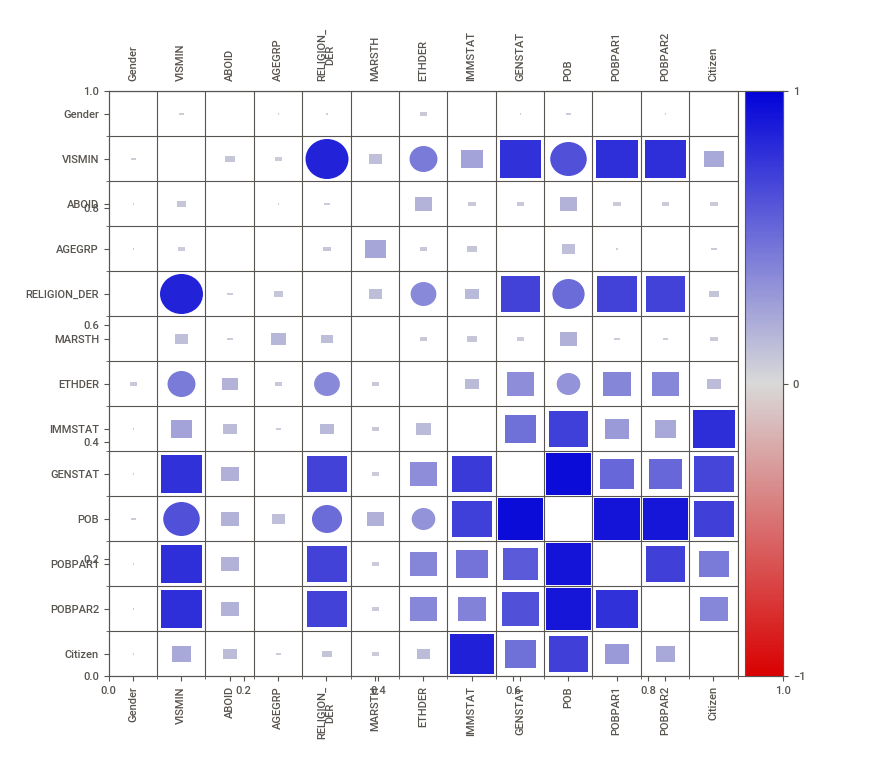
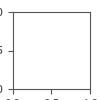

In [6]:
import sweetviz as sv # pip install sweetviz    

fairness_vars = ['Gender', 'VISMIN', 'ABOID', 'AGEGRP', 'RELIGION_DER', 'MARSTH',
                 'ETHDER', 'IMMSTAT', 'GENSTAT', 'POB', 'POBPAR1', 'POBPAR2', 'Citizen']

report = sv.analyze(X[fairness_vars])
report.show_notebook()

## Train test split
We use stratification along the y feature to ensure that the training and the test set have a similar amount of positive and negative examples.

**Do not change the random seed here to ensure that all groups have the same test set**

In [7]:
np.random.seed(42)  # set seed for consistent results
X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(X, y, AGEGRP, random_state=42, stratify=y)

## Fit Random Forest Model to Data

Below we train a random forest estimator as blackbox model for our problem.

**Note**: Hyperparameter tuning might take a while (especially when run online in Google Colab)

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

In [9]:
# Define the parameter grid
param_grid = {
    'n_estimators': [300, 400, 500, 600],
    'max_depth': [10, 15, 20],
    'min_samples_leaf': [20, 30, 40, 50],
    'max_features': [1, 2, 3, 5],
    'class_weight': ['balanced']
}

# Create the GridSearchCV object
stratifier = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           scoring='roc_auc',
                           n_jobs=-1,
                           cv = stratifier)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_
rf = grid_search.best_estimator_
print("Best Parameters:", best_params)
print("Best Score:", best_score)


KeyboardInterrupt: 

**Alternative**: Simply fit the model with the parameters found above

In [10]:
rf = RandomForestClassifier(n_estimators=400, max_depth=15, min_samples_leaf=30, max_features=3, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",30
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",3
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tru

### Analyze fit of the model


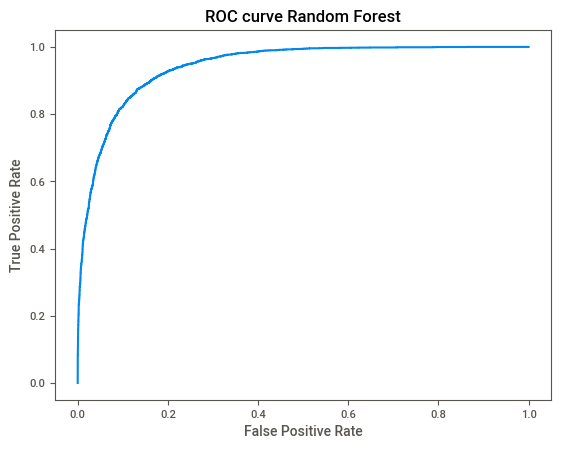

              precision    recall  f1-score   support

           0       0.97      0.84      0.90     11119
           1       0.60      0.90      0.72      3004

    accuracy                           0.85     14123
   macro avg       0.78      0.87      0.81     14123
weighted avg       0.89      0.85      0.86     14123



In [11]:
# predict probabilities of readmission
rf.fit(X_train, y_train)
y_pred = rf.predict_proba(X_test)[:,1]

# plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve Random Forest')
plt.show()

# get classification report and tune threshold in such a way that recall is at least 0.9
threshold = 0.5
print(classification_report(y_test, y_pred > threshold))


In [12]:
print(f" In a group of 1000 individuals approximately {sum(y_pred > threshold) / len(y_pred) * 1000:.0f} have a salary higher than 75k. Amongst these ... \n \
      \t ... {sum((y_test == 1) & (y_pred > threshold)) / len(y_pred) * 1000:.0f} are correctly classified; \n \
      \t ... {sum((y_test == 0) & (y_pred > threshold)) / len(y_pred) * 1000:.0f} are classified as not having a salary higher than 75k. \n \n \
Additionally, we expect that there are {sum((y_test == 1) & (y_pred < threshold)) / len(y_pred) * 1000:.0f} individuals who have a salary higher than 75k but are not classified as such.")

 In a group of 1000 individuals approximately 320 have a salary higher than 75k. Amongst these ... 
       	 ... 192 are correctly classified; 
       	 ... 129 are classified as not having a salary higher than 75k. 
 
 Additionally, we expect that there are 21 individuals who have a salary higher than 75k but are not classified as such.


In [13]:
len(y_pred)

14123

In [14]:
data

,PPSORT,ABOID,AGEGRP,AGEIMM,ATTSCH,BFNMEMB,BEDRM,CFSTAT,CHDBN,CIP2021,...,WT8,WT9,WT10,WT11,WT12,WT13,WT14,WT15,WT16,75k
0,22,6,10,99,1,0,5,4,99999999,4,...,22.892837,22.892837,22.892837,249.188465,22.892837,22.892837,22.892837,22.892837,22.892837,0
1,27,6,11,7,1,0,5,8,99999999,5,...,22.892837,22.892837,22.892837,22.892837,22.892837,22.892837,22.892837,22.892837,22.892837,0
2,42,6,9,99,1,0,1,6,99999999,13,...,22.892837,22.892837,22.892837,22.892837,22.892837,22.892837,249.188465,22.892837,22.892837,0
3,66,6,11,7,1,0,1,6,99999999,5,...,22.892837,22.892837,22.892837,22.892837,22.892837,249.188465,22.892837,22.892837,22.892837,0
4,68,6,11,99,1,0,3,2,2100,13,...,22.892837,22.892837,22.892837,22.892837,22.892837,22.892837,22.892837,22.892837,22.892837,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56485,980820,6,9,99,1,0,2,1,99999999,4,...,22.892837,22.892837,22.892837,249.188465,22.892837,22.892837,22.892837,22.892837,22.892837,0
56486,980827,6,8,99,3,0,3,8,99999999,3,...,22.892837,249.188465,22.892837,22.892837,22.892837,22.892837,22.892837,22.892837,22.892837,0
56487,980832,6,6,99,2,0,4,4,99999999,13,...,22.892837,22.892837,249.188465,22.892837,22.892837,22.892837,22.892837,22.892837,22.892837,0
56488,980859,6,12,7,1,0,3,2,99999999,8,...,22.892837,22.892837,22.892837,22.892837,22.892837,22.892837,249.188465,22.892837,22.892837,1


## Task a: Data Exploration
Before entering the analysis, spend some time to understand the data. 

* Which features do you expect to influence fairness?
* Define groups based on the sensitive feature(s) and visualize the data.
* Are there any inbalances? How might these affect your fairness analysis? 

Use graphs and/or tables, and write down your observations. 


In [3]:
df = pd.read_csv('data_donnees_2021_ind_BC.csv')
print("Minimum AGEGRP:", df["AGEGRP"].min())
print("Maximum AGEGRP:", df["AGEGRP"].max())


Minimum AGEGRP: 6
Maximum AGEGRP: 13


In [4]:
import pandas as pd
import numpy as np


data = df.copy()

# Label mappings
vismin_map = {
    1: "Not a visible minority",
    2: "South Asian",
    3: "Chinese",
    4: "Black",
    5: "Filipino",
    6: "Arab",
    7: "Latin American",
    8: "Southeast Asian",
    9: "West Asian",
    10: "Korean",
    11: "Japanese",
    12: "Visible minority n.i.e.",
    13: "Multiple visible minorities",
    88: "Not available"
}

gender_map = {
    1: "Woman+",
    2: "Man+"
}

agegrp_map = {
    1: "0 to 4 years",
    2: "5 to 6 years",
    3: "7 to 9 years",
    4: "10 to 11 years",
    5: "12 to 14 years",
    6: "15 to 17 years",
    7: "18 to 19 years",
    8: "20 to 24 years",
    9: "25 to 29 years",
    10: "30 to 34 years",
    11: "35 to 39 years",
    12: "40 to 44 years",
    13: "45 to 49 years",
    14: "50 to 54 years",
    15: "55 to 59 years",
    16: "60 to 64 years",
    17: "65 to 69 years",
    18: "70 to 74 years",
    19: "75 to 79 years",
    20: "80 to 84 years",
    21: "85 years and over"
}

# Create readable label columns
data["VISMIN_label"] = data["VISMIN"].map(vismin_map)
data["Gender_label"] = data["Gender"].map(gender_map)
data["AGEGRP_label"] = data["AGEGRP"].map(agegrp_map)

In [5]:
def summarize_categorical_variable(data, column, label_column, group_name):
    total = len(data)
    
    summary = (
        data[label_column]
        .value_counts(dropna=False)
        .reset_index()
    )
    
    summary.columns = ["Feature", "True count"]
    summary["Group Type"] = group_name
    summary["False count"] = total - summary["True count"]
    summary["True %"] = round(summary["True count"] / total * 100, 2)
    summary["False %"] = round(summary["False count"] / total * 100, 2)
    
    summary = summary[
        ["Group Type", "Feature", "True count", "False count", "True %", "False %"]
    ]
    
    return summary


vismin_summary = summarize_categorical_variable(
    data=data,
    column="VISMIN",
    label_column="VISMIN_label",
    group_name="Visible minority"
)

gender_summary = summarize_categorical_variable(
    data=data,
    column="Gender",
    label_column="Gender_label",
    group_name="Gender"
)

age_summary = summarize_categorical_variable(
    data=data,
    column="AGEGRP",
    label_column="AGEGRP_label",
    group_name="Age"
)

combined_summary = pd.concat(
    [vismin_summary, gender_summary, age_summary],
    ignore_index=True
)

combined_summary

,Group Type,Feature,True count,False count,True %,False %
0,Visible minority,Not a visible minority,32926,23564,58.29,41.71
1,Visible minority,South Asian,6551,49939,11.60,88.40
2,Visible minority,Chinese,6423,50067,11.37,88.63
3,Visible minority,Filipino,2273,54217,4.02,95.98
4,Visible minority,Not available,2012,54478,3.56,96.44
5,Visible minority,Southeast Asian,1001,55489,1.77,98.23
6,Visible minority,Latin American,964,55526,1.71,98.29
7,Visible minority,Korean,949,55541,1.68,98.32
8,Visible minority,West Asian,898,55592,1.59,98.41
9,Visible minority,Black,715,55775,1.27,98.73


In [6]:
vismin_order = list(vismin_map.values())
gender_order = list(gender_map.values())
age_order = list(agegrp_map.values())

combined_summary["Feature"] = pd.Categorical(
    combined_summary["Feature"],
    categories=vismin_order + gender_order + age_order,
    ordered=True
)

combined_summary = combined_summary.sort_values(
    ["Group Type", "Feature"]
).reset_index(drop=True)

combined_summary

,Group Type,Feature,True count,False count,True %,False %
0,Age,15 to 17 years,2166,54324,3.83,96.17
1,Age,18 to 19 years,2359,54131,4.18,95.82
2,Age,20 to 24 years,7700,48790,13.63,86.37
3,Age,25 to 29 years,8939,47551,15.82,84.18
4,Age,30 to 34 years,9484,47006,16.79,83.21
5,Age,35 to 39 years,9358,47132,16.57,83.43
6,Age,40 to 44 years,8342,48148,14.77,85.23
7,Age,45 to 49 years,8142,48348,14.41,85.59
8,Gender,Woman+,28327,28163,50.15,49.85
9,Gender,Man+,28163,28327,49.85,50.15


In [7]:
def summarize_income_by_group(data, label_column, group_name):
    summary = (
        data
        .groupby(label_column)["75k"]
        .agg(["count", "mean"])
        .reset_index()
    )
    
    summary.columns = ["Feature", "Count", "Income > 75K rate"]
    summary["Group Type"] = group_name
    summary["Income > 75K rate (%)"] = round(summary["Income > 75K rate"] * 100, 2)
    
    summary = summary[
        ["Group Type", "Feature", "Count", "Income > 75K rate (%)"]
    ]
    
    return summary


vismin_income_summary = summarize_income_by_group(
    data, "VISMIN_label", "Visible minority"
)

gender_income_summary = summarize_income_by_group(
    data, "Gender_label", "Gender"
)

age_income_summary = summarize_income_by_group(
    data, "AGEGRP_label", "Age"
)

income_summary = pd.concat(
    [vismin_income_summary, gender_income_summary, age_income_summary],
    ignore_index=True
)

income_summary

,Group Type,Feature,Count,Income > 75K rate (%)
0,Visible minority,Arab,345,15.36
1,Visible minority,Black,715,14.41
2,Visible minority,Chinese,6423,20.01
3,Visible minority,Filipino,2273,13.59
4,Visible minority,Japanese,550,19.64
5,Visible minority,Korean,949,14.33
6,Visible minority,Latin American,964,17.63
7,Visible minority,Multiple visible minorities,667,19.34
8,Visible minority,Not a visible minority,32926,24.24
9,Visible minority,Not available,2012,14.96


In [8]:
import pandas as pd
import numpy as np

data = df.copy()

# -----------------------------
# 1. Group visible minority categories
# -----------------------------

def group_vismin(x):
    if x == 1:
        return "No visible minority"
    elif x == 4:
        return "Black"
    elif x in [2, 3, 5, 8, 9, 10, 11]:
        return "Asian"
    elif x == 7:
        return "Latin American"
    elif x == 6:
        return "Arab"
    elif x in [12, 13]:
        return "Other visible minority"
    elif x == 88:
        return "Unknown"
    else:
        return "Unknown"

data["VISMIN_grouped"] = data["VISMIN"].apply(group_vismin)


# -----------------------------
# 2. Group age categories
# -----------------------------

def group_age(x):
    if x in [6, 7]:
        return "15 to 19 years"
    elif x in [8, 9]:
        return "20 to 29 years"
    elif x in [10, 11]:
        return "30 to 39 years"
    elif x in [12, 13]:
        return "40 to 49 years"
    else:
        return "Unknown"

data["AGE_grouped"] = data["AGEGRP"].apply(group_age)


# -----------------------------
# 3. Group gender
# -----------------------------

gender_map = {
    1: "Woman+",
    2: "Man+"
}

data["Gender_grouped"] = data["Gender"].map(gender_map)


# -----------------------------
# 4. Summary function
# -----------------------------

def summarize_grouped_variable(data, column, group_name, order=None):
    total = len(data)
    
    summary = (
        data[column]
        .value_counts(dropna=False)
        .reset_index()
    )
    
    summary.columns = ["Feature", "True count"]
    summary["Sensitive Attribute"] = group_name
    summary["False count"] = total - summary["True count"]
    summary["True %"] = round(summary["True count"] / total * 100, 2)
    summary["False %"] = round(summary["False count"] / total * 100, 2)
    
    summary = summary[
        ["Sensitive Attribute", "Feature", "True count", "False count", "True %", "False %"]
    ]
    
    if order is not None:
        summary["Feature"] = pd.Categorical(summary["Feature"], categories=order, ordered=True)
        summary = summary.sort_values("Feature").reset_index(drop=True)
    
    return summary


# -----------------------------
# 5. Create compact summaries
# -----------------------------

vismin_order = [
    "No visible minority",
    "Asian",
    "Black",
    "Latin American",
    "Arab",
    "Other visible minority",
    "Unknown"
]

age_order = [
    "15 to 19 years",
    "20 to 29 years",
    "30 to 39 years",
    "40 to 49 years",
    "Unknown"
]

gender_order = [
    "Woman+",
    "Man+"
]

vismin_summary = summarize_grouped_variable(
    data, "VISMIN_grouped", "Visible minority", vismin_order
)

gender_summary = summarize_grouped_variable(
    data, "Gender_grouped", "Gender", gender_order
)

age_summary = summarize_grouped_variable(
    data, "AGE_grouped", "Age", age_order
)

combined_summary = pd.concat(
    [vismin_summary, gender_summary, age_summary],
    ignore_index=True
)

combined_summary


,Sensitive Attribute,Feature,True count,False count,True %,False %
0,Visible minority,No visible minority,32926,23564,58.29,41.71
1,Visible minority,Asian,18645,37845,33.01,66.99
2,Visible minority,Black,715,55775,1.27,98.73
3,Visible minority,Latin American,964,55526,1.71,98.29
4,Visible minority,Arab,345,56145,0.61,99.39
5,Visible minority,Other visible minority,883,55607,1.56,98.44
6,Visible minority,Unknown,2012,54478,3.56,96.44
7,Gender,Woman+,28327,28163,50.15,49.85
8,Gender,Man+,28163,28327,49.85,50.15
9,Age,15 to 19 years,4525,51965,8.01,91.99
